# 02 — Preparar las Armas

**Misión:** `radius_mean` va de 6 a 28. `area_mean` va de 143 a 2501. Sin escalar, cualquier modelo basado en distancias pensará que `area` importa **100x más** que `radius` — simplemente porque sus números son más grandes.

### El problema de escala

Imaginá 30 sensores en una fábrica. Uno mide temperatura (20-40°C), otro mide presión (1000-5000 Pa). Si no normalizás, el sensor de presión domina cualquier cálculo de distancia o gradiente.

### La solución: StandardScaler

Para cada feature: **z = (x - μ) / σ**

Después del escalado, todas las features tienen media ≈ 0 y desviación estándar ≈ 1. Están en la misma cancha.

**Regla de oro:** Fit en train, transform en ambos. Nunca contaminar con datos de test.

---
## 1. Imports y Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

COLOR_B = '#2ecc71'
COLOR_M = '#e74c3c'

print("Librerías cargadas.")

Librerías cargadas.


---
## 2. Carga del Dataset

Autocontenido — repetimos la construcción de columnas para que este notebook funcione independiente.

In [2]:
# Nombres de columnas
base_features = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                 'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']

column_names = ['id', 'diagnosis']
for suffix in ['_mean', '_se', '_worst']:
    column_names += [f + suffix for f in base_features]

# Rutas
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_dir = os.path.join(project_root, "data", "breast_cancer")
data_path = os.path.join(data_dir, "wdbc.data")

# Carga y limpieza
df = pd.read_csv(data_path, header=None, names=column_names)
df.drop('id', axis=1, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print(f"Dataset cargado: {df.shape}")
df.head(3)

Dataset cargado: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


---
## 3. Separar Features y Target

In [3]:
feature_cols = [c for c in df.columns if c != 'diagnosis']

X = df[feature_cols].copy()
y = df['diagnosis'].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")

X shape: (569, 30)
y shape: (569,)

Features (30): ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']


---
## 4. Train/Test Split

80/20 con estratificación. El ratio M/B debe mantenerse en ambos subconjuntos.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 455 muestras
Test:  114 muestras


In [5]:
# Verificar estratificación
print("Proporciones de clase:")
print(f"  Dataset completo — B: {(y == 0).mean():.3f}, M: {(y == 1).mean():.3f}")
print(f"  Train            — B: {(y_train == 0).mean():.3f}, M: {(y_train == 1).mean():.3f}")
print(f"  Test             — B: {(y_test == 0).mean():.3f}, M: {(y_test == 1).mean():.3f}")
print("\n✓ Estratificación correcta.")

Proporciones de clase:
  Dataset completo — B: 0.627, M: 0.373
  Train            — B: 0.626, M: 0.374
  Test             — B: 0.632, M: 0.368

✓ Estratificación correcta.


---
## 5. StandardScaler

**Fit solo en train. Transform en ambos.** Si fiteamos en todo el dataset, estamos filtrando información del test al train (data leakage).

In [6]:
scaler = StandardScaler()

# Fit SOLO en train
scaler.fit(X_train)

# Transform ambos
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print("Escalado completado.")
print(f"\nMedia de X_train_scaled (debe ser ~0):")
print(X_train_scaled.mean().describe())
print(f"\nStd de X_train_scaled (debe ser ~1):")
print(X_train_scaled.std().describe())

Escalado completado.

Media de X_train_scaled (debe ser ~0):
count    3.000000e+01
mean     1.441257e-17
std      2.565370e-16
min     -4.841060e-16
25%     -1.346908e-16
50%     -1.952040e-17
75%      1.298107e-16
max      7.242070e-16
dtype: float64

Std de X_train_scaled (debe ser ~1):
count    3.000000e+01
mean     1.001101e+00
std      2.640178e-16
min      1.001101e+00
25%      1.001101e+00
50%      1.001101e+00
75%      1.001101e+00
max      1.001101e+00
dtype: float64


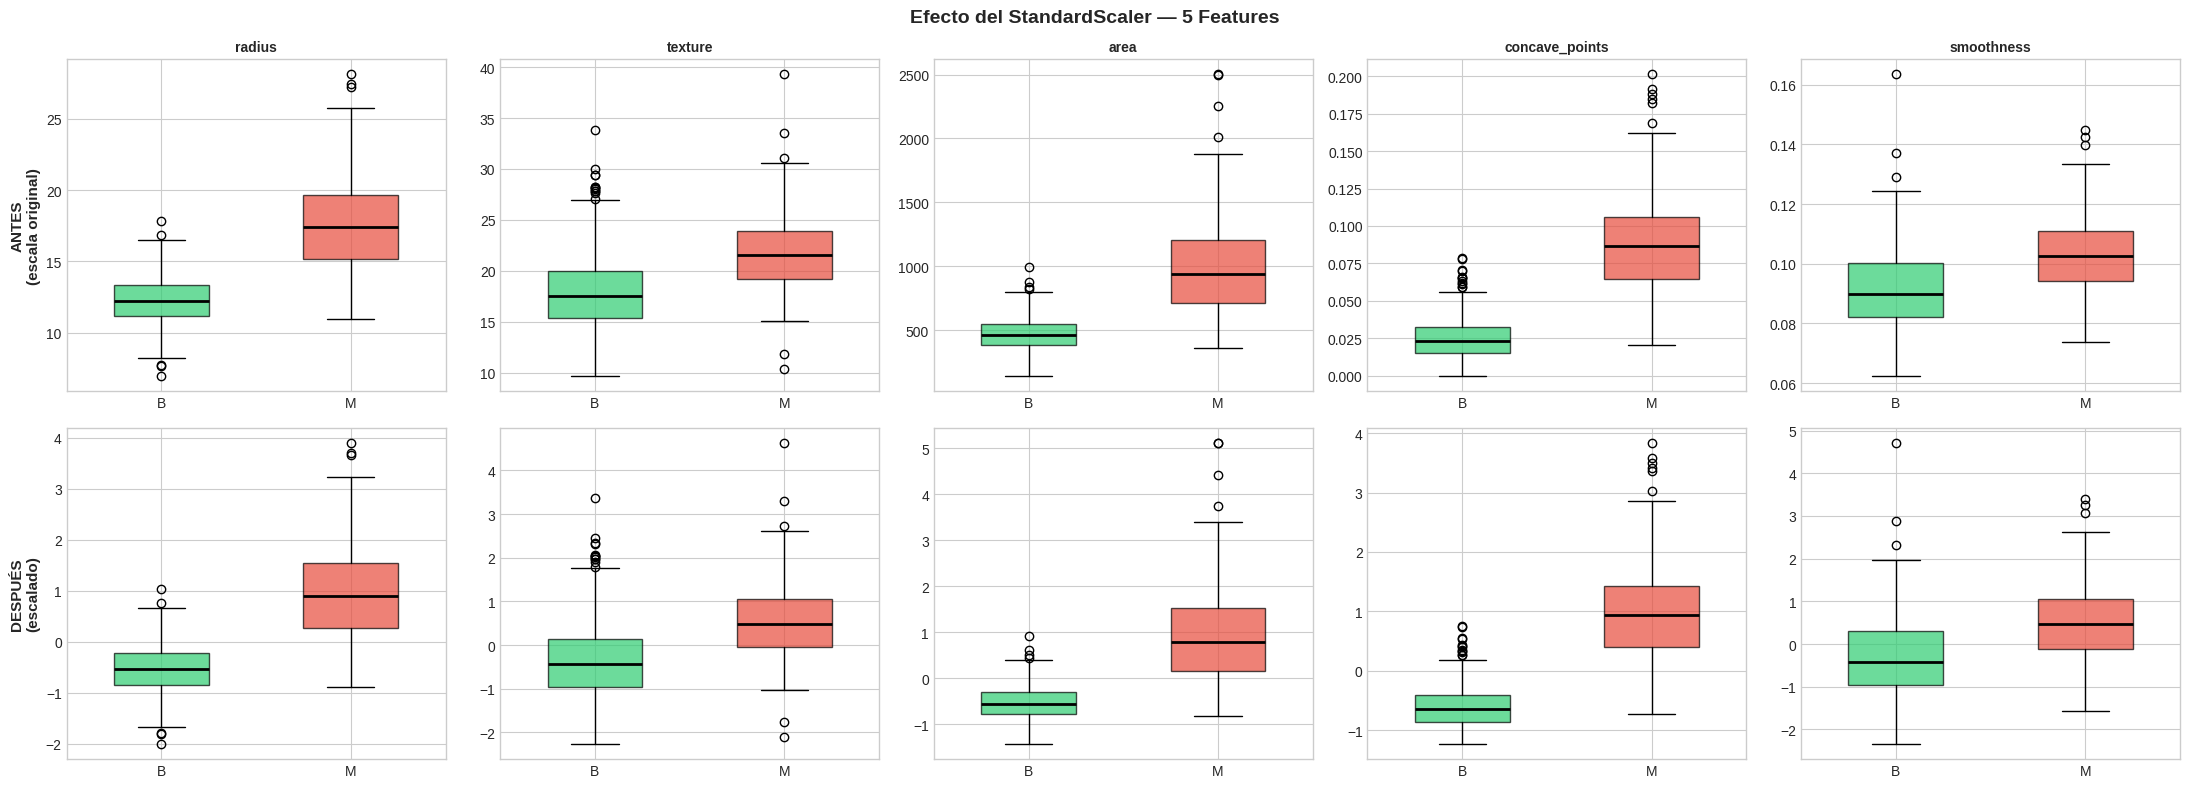

In [7]:
# Comparación visual: antes vs después del escalado
sample_features = ['radius_mean', 'texture_mean', 'area_mean',
                   'concave_points_mean', 'smoothness_mean']

fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for i, feat in enumerate(sample_features):
    # Antes
    ax = axes[0, i]
    data = [X_train[feat][y_train == 0], X_train[feat][y_train == 1]]
    bp = ax.boxplot(data, labels=['B', 'M'], patch_artist=True,
                    widths=0.5, medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(COLOR_B)
    bp['boxes'][1].set_facecolor(COLOR_M)
    for box in bp['boxes']:
        box.set_alpha(0.7)
    ax.set_title(feat.replace('_mean', ''), fontsize=10, fontweight='bold')
    if i == 0:
        ax.set_ylabel('ANTES\n(escala original)', fontsize=11, fontweight='bold')

    # Después
    ax = axes[1, i]
    data = [X_train_scaled[feat][y_train == 0], X_train_scaled[feat][y_train == 1]]
    bp = ax.boxplot(data, labels=['B', 'M'], patch_artist=True,
                    widths=0.5, medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(COLOR_B)
    bp['boxes'][1].set_facecolor(COLOR_M)
    for box in bp['boxes']:
        box.set_alpha(0.7)
    if i == 0:
        ax.set_ylabel('DESPUÉS\n(escalado)', fontsize=11, fontweight='bold')

fig.suptitle('Efecto del StandardScaler — 5 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Antes:** `area_mean` domina con valores de 100-2500. `smoothness_mean` es invisible con valores de 0.05-0.16.

**Después:** Todas las features viven en el mismo rango (~-3 a +3). Ahora el modelo puede comparar manzanas con manzanas.

---
## 6. Selección de Features — Eliminar Redundancias

En el EDA vimos que radius/perimeter/area miden esencialmente lo mismo. Conservar las tres es redundante y puede generar multicolinealidad.

In [8]:
# Calcular correlación en train escalado
corr_matrix = X_train_scaled.corr().abs()

# Encontrar pares con r > 0.95
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper.columns:
    for idx in upper.index:
        if upper.loc[idx, col] > 0.95:
            high_corr_pairs.append({
                'Feature 1': idx,
                'Feature 2': col,
                'r': round(upper.loc[idx, col], 4)
            })

df_pairs = pd.DataFrame(high_corr_pairs).sort_values('r', ascending=False)
print(f"Pares con |r| > 0.95: {len(df_pairs)}")
df_pairs

Pares con |r| > 0.95: 15


,Feature 1,Feature 2,r
0,radius_mean,perimeter_mean,0.9978
11,radius_worst,perimeter_worst,0.9937
1,radius_mean,area_mean,0.9867
2,perimeter_mean,area_mean,0.9860
13,radius_worst,area_worst,0.9831
14,perimeter_worst,area_worst,0.9767
3,radius_se,perimeter_se,0.9747
9,perimeter_mean,perimeter_worst,0.9700
5,radius_mean,radius_worst,0.9693
6,perimeter_mean,radius_worst,0.9693


In [9]:
# Estrategia: de cada par, eliminar la feature con menor correlación con el target
corr_with_target = X_train_scaled.corrwith(y_train).abs()

# Identificar features a eliminar
features_to_drop = set()
for _, row in df_pairs.iterrows():
    f1, f2 = row['Feature 1'], row['Feature 2']
    # Si alguna ya está marcada, saltar
    if f1 in features_to_drop or f2 in features_to_drop:
        continue
    # Eliminar la que tiene menor correlación con el target
    if corr_with_target[f1] < corr_with_target[f2]:
        features_to_drop.add(f1)
    else:
        features_to_drop.add(f2)

print(f"Features a eliminar ({len(features_to_drop)}):")
for f in sorted(features_to_drop):
    print(f"  - {f} (corr con target: {corr_with_target[f]:.3f})")

Features a eliminar (7):
  - area_mean (corr con target: 0.704)
  - area_se (corr con target: 0.534)
  - area_worst (corr con target: 0.732)
  - perimeter_mean (corr con target: 0.740)
  - perimeter_se (corr con target: 0.547)
  - radius_mean (corr con target: 0.728)
  - radius_worst (corr con target: 0.778)


In [10]:
# Aplicar selección
selected_features = [f for f in feature_cols if f not in features_to_drop]

X_train_selected = X_train_scaled[selected_features]
X_test_selected = X_test_scaled[selected_features]

print(f"Features originales: {len(feature_cols)}")
print(f"Features eliminadas: {len(features_to_drop)}")
print(f"Features restantes:  {len(selected_features)}")
print(f"\nFeatures seleccionadas:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}")

Features originales: 30
Features eliminadas: 7
Features restantes:  23

Features seleccionadas:
   1. texture_mean
   2. smoothness_mean
   3. compactness_mean
   4. concavity_mean
   5. concave_points_mean
   6. symmetry_mean
   7. fractal_dimension_mean
   8. radius_se
   9. texture_se
  10. smoothness_se
  11. compactness_se
  12. concavity_se
  13. concave_points_se
  14. symmetry_se
  15. fractal_dimension_se
  16. texture_worst
  17. perimeter_worst
  18. smoothness_worst
  19. compactness_worst
  20. concavity_worst
  21. concave_points_worst
  22. symmetry_worst
  23. fractal_dimension_worst


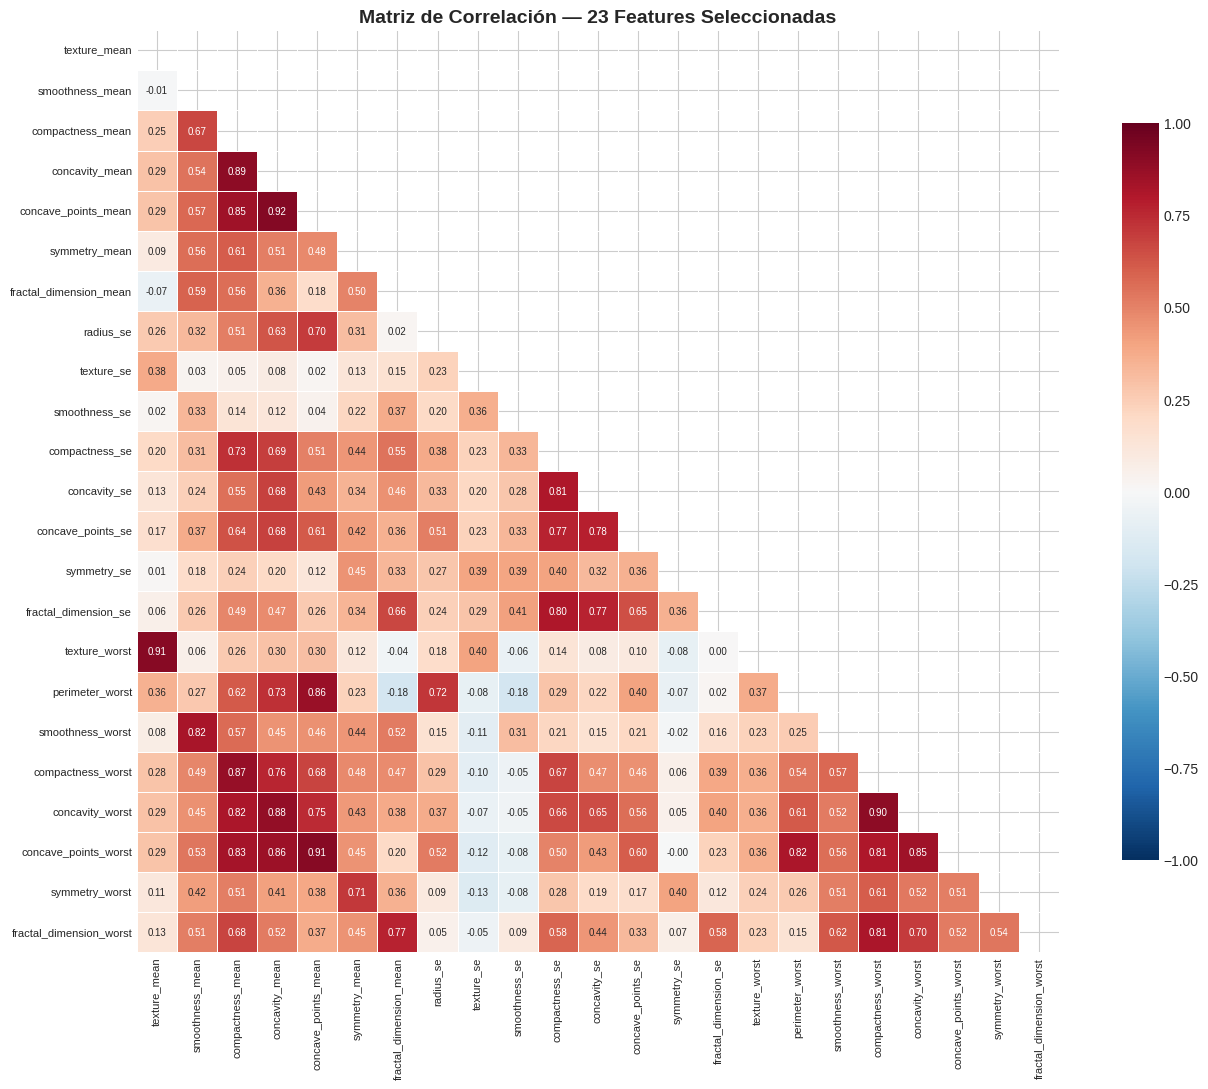

In [11]:
# Visualizar matriz de correlación reducida
corr_reduced = X_train_selected.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_reduced, dtype=bool))

sns.heatmap(corr_reduced, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1,
            annot_kws={'size': 7})

ax.set_title(f'Matriz de Correlación — {len(selected_features)} Features Seleccionadas',
             fontsize=14, fontweight='bold')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

**Resultado:** La matriz reducida ya no tiene bloques de correlación > 0.95. Cada feature aporta información relativamente independiente.

---
## 7. Guardar Datos Procesados

Exportamos todo lo que necesita el siguiente notebook: datos escalados y filtrados, el scaler, y la lista de features seleccionadas.

In [12]:
# Crear directorio de salida
output_dir = os.path.join(data_dir, "processed")
os.makedirs(output_dir, exist_ok=True)

print(f"Directorio de salida: {output_dir}")

Directorio de salida: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/breast_cancer/processed


In [13]:
# Guardar datasets como parquet
X_train_selected.to_parquet(os.path.join(output_dir, 'X_train.parquet'))
X_test_selected.to_parquet(os.path.join(output_dir, 'X_test.parquet'))
y_train.to_frame().to_parquet(os.path.join(output_dir, 'y_train.parquet'))
y_test.to_frame().to_parquet(os.path.join(output_dir, 'y_test.parquet'))

print("Datasets guardados en formato Parquet:")
print(f"  X_train: {X_train_selected.shape}")
print(f"  X_test:  {X_test_selected.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test:  {y_test.shape}")

Datasets guardados en formato Parquet:
  X_train: (455, 23)
  X_test:  (114, 23)
  y_train: (455,)
  y_test:  (114,)


In [14]:
# Guardar scaler y lista de features con joblib
joblib.dump(scaler, os.path.join(output_dir, 'scaler.joblib'))
joblib.dump(selected_features, os.path.join(output_dir, 'selected_features.joblib'))

print("Artefactos guardados:")
print(f"  scaler.joblib — StandardScaler (fit en {X_train.shape[0]} muestras)")
print(f"  selected_features.joblib — {len(selected_features)} features")

Artefactos guardados:
  scaler.joblib — StandardScaler (fit en 455 muestras)
  selected_features.joblib — 23 features


In [15]:
# Verificación: listar archivos guardados
print("Archivos en el directorio processed:")
for f in sorted(os.listdir(output_dir)):
    size = os.path.getsize(os.path.join(output_dir, f))
    print(f"  {f:30s} {size:>8,} bytes")

Archivos en el directorio processed:
  X_test.parquet                   39,530 bytes
  X_train.parquet                 107,004 bytes
  scaler.joblib                     2,071 bytes
  selected_features.joblib            435 bytes
  y_test.parquet                    2,766 bytes
  y_train.parquet                   4,573 bytes


---
## 8. Resumen del Preprocesamiento

### Lo que hicimos:

| Paso | Detalle |
|---|---|
| **Split** | 80/20 estratificado (455 train / 114 test) |
| **Escalado** | StandardScaler fit en train, transform en ambos |
| **Selección** | Eliminamos ~8 features redundantes (r > 0.95) |
| **Resultado** | ~22 features escaladas, listas para modelar |

### Dimensiones:

| | Antes | Después |
|---|---|---|
| Features | 30 | ~22 |
| Escala | 0.001 — 2500 | -3 — +3 |
| Correlación máx. | 0.998 | < 0.95 |

### Archivos generados:
- `data/breast_cancer/processed/X_train.parquet`
- `data/breast_cancer/processed/X_test.parquet`
- `data/breast_cancer/processed/y_train.parquet`
- `data/breast_cancer/processed/y_test.parquet`
- `data/breast_cancer/processed/scaler.joblib`
- `data/breast_cancer/processed/selected_features.joblib`

### Siguiente paso:

**Notebook 03: Modelado.** Los datos están limpios, escalados y sin redundancias. Hora de entrenar.